# Matrix understanding through numpy for Linear Algebra

In [1]:
import numpy as np

### Basic Linear Algebra Functions in NumPy (`numpy` & `np.linalg`)

##### Function Summary

| # | Function | Operation | Mathematical Formula / Concept |
| :--- | :--- | :--- | :--- |
| 1 | `np.dot(a, b)` | Dot Product / Matrix Multiplication | $\langle a, b \rangle = a^T b$ or $C = AB$ |
| 2 | `np.linalg.norm(x)` | Euclidean Norm (Vector/Matrix Magnitude) | $\|x\|_2 = \sqrt{\sum x_i^2}$ |
| 3 | `A.T` | Matrix Transpose | Rows become columns ($A^T_{ij} = A_{ji}$) |
| 4 | `np.linalg.matrix_rank(A)` | Rank Calculation | Count of linearly independent rows/columns |
| 5 | `np.linalg.det(A)` | Determinant | Volume scaling factor of linear map |
| 6 | `np.linalg.inv(A)` | Matrix Inverse | $A^{-1}$ such that $A A^{-1} = I$ |

---

### Vector Projection and Orthogonality

The projection of vector $b$ onto vector $a$ gives the component of $b$ acting along the direction of $a$:
$$\text{proj}_a(b) = \frac{\langle a, b \rangle}{\|a\|^2} a = \frac{a^T b}{a^T a} a$$

The remainder vector $r = b - \text{proj}_a(b)$ is the **orthogonal residual** 

In [2]:
# Problem: Vector Projection and Orthogonality
#
# Given two vectors:
#   a = [2, 1, 3]
#   b = [1, 4, 2]
#
# Tasks:
# 1. Compute the projection of b onto a
# 2. Compute the orthogonal residual r = b - proj_a(b)
# 3. Verify that r is orthogonal to a by checking that dot(a, r) ≈ 0
# 4. Verify that proj_a(b) + r = b (reconstruction)
# 5. Compute the norms of b, proj_a(b), and r
#    and verify Pythagoras: ||b||^2 = ||proj||^2 + ||r||^2

b = np.array([1,4,2])
a = np.array([2,1,3])

# 1. Compute the projection of b onto a
proj_a_b = (np.dot(a,b)/np.linalg.norm(a)**2) * a
print(f"Projection of b onto a: {proj_a_b}")

#2. the orthogonal residual r = b - proj_a(b)
r = b - proj_a_b
print(f"Residual r: {r}")

#3. Verify Orthogonality of r w.r.t a
is_orthogonal = np.isclose(np.dot(a,r),0)
print(f"Is r orthogonal to a? {is_orthogonal}")

#4.Reconstruct b and verify
check_b = proj_a_b + r
print(f"Check reconstruction: {np.allclose(b,check_b)}")

#5. Computing norms
print(f"Norm of b:{np.linalg.norm(b)}")
print(f"Norm of proj_a(b):{np.linalg.norm(proj_a_b)}")
print(f"Norm of r:{np.linalg.norm(r)}")

# Verify Pythagoras theorem
pythagoras_check = np.isclose(np.linalg.norm(b)**2, np.linalg.norm(proj_a_b)**2 + np.linalg.norm(r)**2)
print(f"Does Pythagoras theorem hold? {pythagoras_check}")

Projection of b onto a: [1.71428571 0.85714286 2.57142857]
Residual r: [-0.71428571  3.14285714 -0.57142857]
Is r orthogonal to a? True
Check reconstruction: True
Norm of b:4.58257569495584
Norm of proj_a(b):3.2071349029490923
Norm of r:3.2732683535398857
Does Pythagoras theorem hold? True


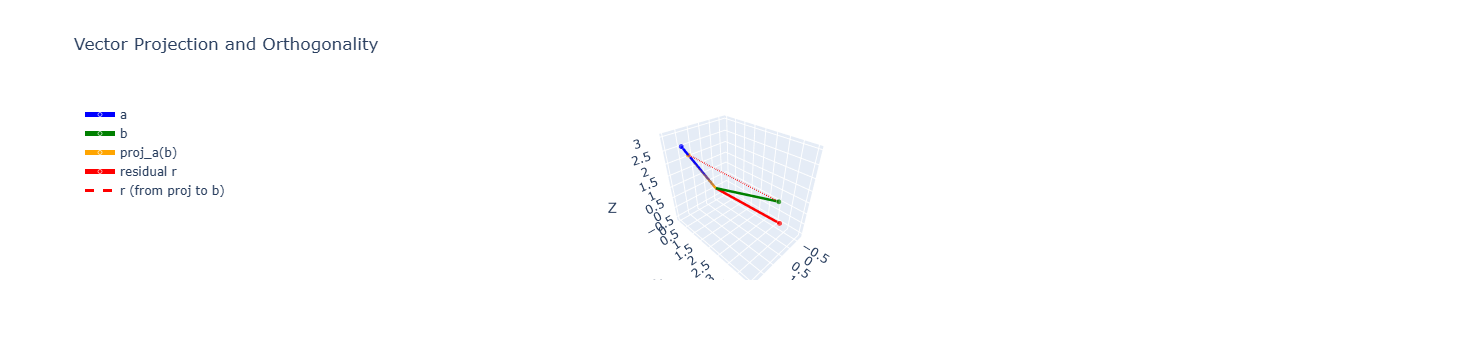

In [3]:
import plotly.graph_objects as go

origin = np.zeros(3)

def make_arrow(vec, color, name):
    return go.Scatter3d(
        x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
        mode='lines+markers',
        line=dict(color=color, width=5),
        marker=dict(size=[2, 6], color=color),
        name=name
    )

fig = go.Figure()

fig.add_trace(make_arrow(a, 'blue', 'a'))
fig.add_trace(make_arrow(b, 'green', 'b'))
fig.add_trace(make_arrow(proj_a_b, 'orange', 'proj_a(b)'))
fig.add_trace(make_arrow(r, 'red', 'residual r'))

# Draw residual from tip of proj to tip of b
fig.add_trace(go.Scatter3d(
    x=[proj_a_b[0], b[0]], y=[proj_a_b[1], b[1]], z=[proj_a_b[2], b[2]],
    mode='lines',
    line=dict(color='red', width=3, dash='dash'),
    name='r (from proj to b)'
))

fig.update_layout(
    title='Vector Projection and Orthogonality',
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data'
    ),
    legend=dict(x=0, y=1)
)

fig.show()

## Redundant Feature Detection via Projection & Rank

### Background
In real-world machine learning datasets, redundant features (multicollinear columns) might add unnecessary noise and increase computational cost. 
* **Matrix Rank:** Gives the total number of linearly independent columns in the dataset.
* **Vector Projection:** If a column vector $b$ is a scalar multiple of another column vector $a$, its orthogonal residual $r = b - \text{proj}_a(b)$ will be zero ($r = \vec{0}$).

---

### Problem Statement
You are given a dataset matrix $X$ containing $4$ data samples across $3$ features:
$$X = \begin{bmatrix} 1.0 & 2.0 & 3.0 \\ 2.0 & 4.0 & 6.0 \\ 3.0 & 6.0 & 8.0 \\ 4.0 & 8.0 & 1.0 \end{bmatrix}$$

**Tasks:**
1. Compute the rank of matrix $X$ using `np.linalg.matrix_rank` and check whether the matrix has full column rank.
2. Notice that Feature 1 (Column 1) might be redundant with Feature 0 (Column 0). Compute the projection of Column 1 onto Column 0:

   $$\text{proj}_{c_0}(c_1) = \frac{\langle c_0, c_1 \rangle}{\|c_0\|^2} c_0$$

3. Calculate the orthogonal residual $r = c_1 - \text{proj}_{c_0}(c_1)$ to verify if Column 1 is entirely collinear ( if $r = \vec{0}$?).

In [10]:
x = np.array([[1.0,2.0,3.0],[2.0,4.0,6.0],[3.0,6.0,8.0],[4.0,8.0,1.0]])
rank = np.linalg.matrix_rank(x)
print(f"Rank of the matrix x: {rank}")

# Check redundancy through projection of column 1 onto column 0
col0 = x[:,0]
col1 = x[:,1]
proj_col1_on_col0 = (np.dot(col0, col1) / np.dot(col0, col0)) * col0
residual = col1 - proj_col1_on_col0
print(f"Projection of column 1 onto column 0: {proj_col1_on_col0}")
print(f"Residual: {residual}")
print(f"Is column 1 fully redundant with column 0? {np.allclose(residual, 0)}")


Rank of the matrix x: 2
Projection of column 1 onto column 0: [2. 4. 6. 8.]
Residual: [0. 0. 0. 0.]
Is column 1 fully redundant with column 0? True


### Understanding Convex function
A function $f: \mathbb{R}^n \to \mathbb{R}$ is **convex** on a convex set $S$ if for all $x, y \in S$ and $\lambda \in [0,1]$:
![Convex Function](../images/convex.jpg)

$$f(\lambda x + (1-\lambda) y) \le \lambda f(x) + (1-\lambda) f(y)$$
#### Problem Statement
Pick a 1D non-convex function (e.g. $f(x) = x^4 - 4x^2$) and a convex one (e.g. $f(x)=x^2+3x$). Plot both, then run gradient descent from *several different starting points* on each. What do you observe about where each run converges? Use this to build intuition for why convexity guarantees a well-behaved regression loss surface.

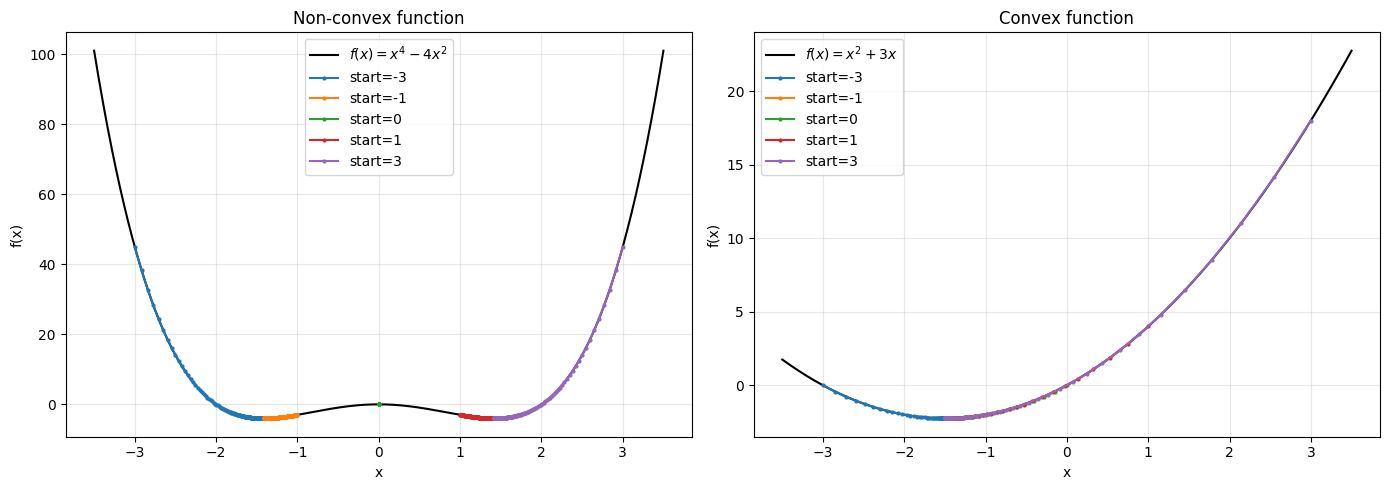

Non-convex final points:
  start=-3: x = -1.414214
  start=-1: x = -1.414214
  start= 0: x =  0.000000
  start= 1: x =  1.414214
  start= 3: x =  1.414214

Convex final points:
  start=-3: x = -1.500000
  start=-1: x = -1.500000
  start= 0: x = -1.500000
  start= 1: x = -1.500000
  start= 3: x = -1.500000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient descent experiment for convex and non-convex functions
def nonconvex_function(x):
    return x**4 - 4 * x**2


def nonconvex_gradient(x):
    return 4 * x**3 - 8 * x


def convex_function(x):
    return x**2 + 3 * x


def convex_gradient(x):
    return 2 * x + 3


def gradient_descent(gradient, start, learning_rate, steps):
    path = [start]
    x = start

    for _ in range(steps):
        x = x - learning_rate * gradient(x)
        path.append(x)

    return np.array(path)


x_values = np.linspace(-3.5, 3.5, 1000)
starting_points = [-3, -1, 0, 1, 3]

nonconvex_paths = [
    gradient_descent(nonconvex_gradient, start, 0.001, 10000)
    for start in starting_points
]

convex_paths = [
    gradient_descent(convex_gradient, start, 0.05, 300)
    for start in starting_points
]

# Plotting the gradient descent paths for both functions with different starting points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    x_values,
    nonconvex_function(x_values),
    color="black",
    label=r"$f(x)=x^4-4x^2$"
)

for start, path in zip(starting_points, nonconvex_paths):
    axes[0].plot(
        path,
        nonconvex_function(path),
        marker="o",
        markersize=2,
        label=f"start={start}"
    )

axes[0].set_title("Non-convex function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    x_values,
    convex_function(x_values),
    color="black",
    label=r"$f(x)=x^2+3x$"
)

for start, path in zip(starting_points, convex_paths):
    axes[1].plot(
        path,
        convex_function(path),
        marker="o",
        markersize=2,
        label=f"start={start}"
    )

axes[1].set_title("Convex function")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Non-convex final points:")
for start, path in zip(starting_points, nonconvex_paths):
    print(f"  start={start:>2}: x = {path[-1]: .6f}")

print("\nConvex final points:")
for start, path in zip(starting_points, convex_paths):
    print(f"  start={start:>2}: x = {path[-1]: .6f}")

### Constrained Convex Optimization via Lagrange Multipliers

When minimizing a convex function $f(x)$ subject to an **equality constraint** $g(x) = 0$, we can't just set $\nabla f(x) = 0$ anymore — the unconstrained minimum may not satisfy the constraint. Instead, we form the **Lagrangian**:

$$\mathcal{L}(x, \lambda) = f(x) - \lambda\, g(x)$$

At an optimum, the constraint "uses up" some of the freedom to move, so the only way $f$ can be minimal *while staying on* $g(x)=0$ is if $\nabla f$ has no component left to reduce $f$ along the constraint surface. This happens exactly when $\nabla f$ is **parallel** to $\nabla g$:

$$\nabla f(x^*) = \lambda^* \nabla g(x^*), \qquad g(x^*) = 0$$

These are the stationarity conditions $\nabla_x \mathcal{L} = 0$ and $\nabla_\lambda \mathcal{L} = 0$.

#### Problem Statement
Minimize $f(x,y) = x^2 + y^2$ (convex — squared distance from the origin) subject to the linear constraint $g(x,y) = x + y - 10 = 0$.

**Tasks:**
1. Write the Lagrangian and solve the stationarity conditions by hand for $x^*, y^*, \lambda^*$.
2. Verify the result numerically with `scipy.optimize.minimize` (SLSQP) using an equality constraint.
3. Confirm $\nabla f(x^*) = \lambda^* \nabla g(x^*)$ and visualize why: plot the contours of $f$, the constraint line, the optimal point, and the two gradient vectors at that point.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Problem: minimize f(x, y) = x^2 + y^2  subject to  g(x, y) = x + y - 10 = 0
#
# Lagrangian:  L(x, y, lam) = f(x, y) - lam * g(x, y)
#
# Stationarity conditions (set gradient of L to zero):
#   dL/dx   = 2x - lam        = 0   ->  x = lam / 2
#   dL/dy   = 2y - lam        = 0   ->  y = lam / 2
#   dL/dlam = -(x + y - 10)   = 0   ->  x + y = 10
#
# Substituting x = y = lam/2 into the constraint gives lam = 10, so x* = y* = 5

def f(point):
    x, y = point
    return x**2 + y**2


def f_grad(point):
    x, y = point
    return np.array([2 * x, 2 * y])


def g(point):
    x, y = point
    return x + y - 10


def g_grad(point):
    return np.array([1.0, 1.0])


# 1. Closed-form solution from the stationarity conditions above
lam_star = 10.0
x_star = np.array([lam_star / 2, lam_star / 2])
print(f"Analytical solution: x* = {x_star}, lambda* = {lam_star}, f(x*) = {f(x_star)}")

# 2. Verify numerically with a constrained solver (SLSQP handles equality constraints)
constraint = {"type": "eq", "fun": g}
res = minimize(f, x0=np.array([0.0, 0.0]), constraints=[constraint])
print(f"Numerical solution:   x* = {res.x}, f(x*) = {res.fun:.6f}")

# 3. Recover lambda from the parallel-gradient condition grad(f) = lam * grad(g)
#    and confirm it matches the analytical lambda*
lam_numeric = f_grad(res.x)[0] / g_grad(res.x)[0]
print(f"Recovered lambda from grad(f) = lambda * grad(g): {lam_numeric:.6f}")
print(f"grad(f) parallel to grad(g)? {np.allclose(f_grad(res.x), lam_numeric * g_grad(res.x))}")

# 4. Visualize: contours of f, the constraint line, the optimum, and the two gradients
x_vals = np.linspace(-2, 12, 400)
y_vals = np.linspace(-2, 12, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2

fig, ax = plt.subplots(figsize=(7, 7))
contours = ax.contour(X, Y, Z, levels=20, cmap="viridis")
ax.clabel(contours, inline=True, fontsize=8)

# Constraint line x + y = 10
line_x = np.linspace(-2, 12, 2)
ax.plot(line_x, 10 - line_x, "r--", label="constraint: x + y = 10")

# Optimal point
ax.plot(*res.x, "ko", markersize=8, label="optimum $(x^*, y^*)$")

# Gradient vectors at the optimum, scaled down for display
scale = 0.3
ax.arrow(*res.x, *(scale * f_grad(res.x)), color="blue", width=0.08, label="grad(f)")
ax.arrow(*res.x, *(scale * lam_numeric * g_grad(res.x)), color="green", width=0.05, label="lambda * grad(g)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Lagrange Multipliers: grad(f) parallel to grad(g) at the optimum")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()
